In [ ]:
from firedrake import *
from firedrake.output import VTKFile
import matplotlib.pyplot as plt
import numpy as np
from firedrake.petsc import PETSc
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
io_path = current_path + "/cfd-labs/Lab10-NS-stabilization/" 
print(io_path)

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


/home/aless/cfd-labs/Lab09-Stabilizations/


# Ex.1 NS: Stabilization (1).

We want to solve the following problem for non dimensional Navier-Stokes equations

\begin{equation*}
\begin{cases}
(\boldsymbol{u}\cdot\nabla)\boldsymbol{u} - \frac{1}{\rm Re}\Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = \boldsymbol{i} & {\rm on} \ \Gamma_{\rm up}, \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on}\ \Gamma_{\rm wall}=\partial\Omega\setminus\Gamma_{\rm up}. \\
\end{cases}
\end{equation*}

In particular we want to apply Brezzi-Pitkäranta and SUPG stabilization.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

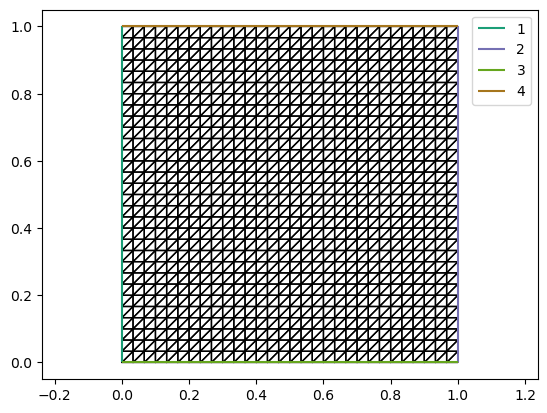

In [3]:
# Build the mesh
N = 30
mesh = UnitSquareMesh(N, N, diagonal='right')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()
ax.axis('equal')

In [144]:
# Function spaces (mixed formulation)
V = VectorFunctionSpace(mesh, 'P', 1)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])

# Viscosity and source term
Re = 3000.0
f = Constant((0.,0.))

# Boundary conditions
x = SpatialCoordinate(mesh)
bc_up = DirichletBC(W.sub(0), Constant((1.0, 0.0)), 4)
bc_rest = DirichletBC(W.sub(0), Constant((0.0, 0.0)), [1, 2, 3])
bcs = [bc_up, bc_rest]

# Null space
nullspace = MixedVectorSpaceBasis(W, [W.sub(0),VectorSpaceBasis(constant=True, comm=COMM_WORLD)])

# Variational problem
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

def nonlinear_iteration_forms(u, v, p, q, Re, f, u_old, delta=None, BrezziPitkaranta=False, SUPG=False):
    """
    Nonlinear iteration: solve the Navier-Stokes equations using Picard iteration.
    """
    # Fixed-point iteration
    a_fp = Constant(1.0/Re) * inner(grad(u), grad(v)) * dx + inner(dot(grad(u), u_old), v) * dx + 0.5 * div(u_old) * dot(u, v) * dx - div(v) * p * dx + q * div(u) * dx
    L_fp = dot(f, v) * dx

    # Brezzi-Pitkaranta stabilization
    if BrezziPitkaranta:
        delta = Constant(0.01) if delta is None else delta
        h = CellDiameter(mesh)
        a_fp += delta * h**2 * Re * inner(grad(p), grad(q)) * dx
    elif SUPG:
        delta = Constant(0.01) if delta is None else delta
        h = CellDiameter(mesh)
        ubar = Function(FunctionSpace(mesh, "DG", 0))
        ubar.project(sqrt(dot(u_old, u_old)))
        ReK = Re * ubar * h
        one = Constant(1.0)
        deltaK = delta * conditional(lt(ReK, one), h/(ubar+1e-10), h**2 * Re)
        a_fp += deltaK * inner(- 1.0/Re * div(grad(u)) + dot(grad(u), u_old) + 0.5 * div(u_old) * u + grad(p), dot(grad(v), u_old) + 0.5 * div(u_old) * v + grad(q)) * dx + deltaK * div(u) * div(v) * dx
        L_fp += deltaK * inner(f, dot(grad(v), u_old) + 0.5 * div(u_old) * v + grad(q)) * dx
    return a_fp, L_fp

In [145]:
# Initialization: wh = 0
wh = Function(W)
uh, ph = wh.subfunctions

# ----------------------------------------------------------------------
# ATTENTION: do not use 'u_old = uh', which would yield a "shallow copy"
# ----------------------------------------------------------------------
u_old = Function(V)
u_old.assign(uh)
p_old = Function(Q)
p_old.assign(ph)

USE_SUPG = True

In [147]:
# vtk output for Paraview
basename = 'ex1'
if USE_SUPG:
    basename = basename + '_SUPG'
basename = basename + '_Re' + str(int(Re))
outfile = VTKFile(io_path+"output/"+basename+"solution.pvd")
uh.rename("Velocity")
ph.rename("Pressure")
outfile.write(uh, ph)

In [148]:
# Iterative algorithm

maxit = 100
it = 0
tol = 1e-3
err = tol+1
param = {'ksp_type': 'preonly', 'pc_type': 'lu', 'pc_factor_mat_solver_type': 'mumps'}

while it <= maxit and err > tol:
    it += 1

    # solve problem and compute error
    a, L = nonlinear_iteration_forms(u, v, p, q, Re, f, u_old, delta = 0.01, BrezziPitkaranta=not USE_SUPG, SUPG=USE_SUPG)
    problem = LinearVariationalProblem(a, L, wh, bcs=bcs)
    solver =  LinearVariationalSolver(problem, solver_parameters=param, nullspace=nullspace)
    solver.solve()
    uh, ph = wh.subfunctions
    if it != 1:
        err = errornorm(uh, u_old, 'H1') / norm(u_old, 'H1') + errornorm(ph, p_old, 'L2') / norm(p_old, 'L2')
    else:
        err = float('inf')

    print("--------------------------------")
    print(f"Step : {it}")
    print(f"Error: {err}")
    uh.rename("Velocity")
    ph.rename("Pressure")
    outfile.write(uh, ph)

    # update the old solution
    u_old.assign(uh)
    p_old.assign(ph)

print("--------------------------------")

if it <= maxit:
    print('Nonlinear solver converged in', it, 'iterations.')
else:
    print('Nonlinear solver did NOT converge!\nRelative error =', err, 'after', it, 'iterations.')
print("--------------------------------")

--------------------------------
Step : 1
Error: inf
--------------------------------
Step : 2
Error: 42992002.70304062
--------------------------------
Step : 3
Error: 0.5647635000159815
--------------------------------
Step : 4
Error: 0.12433731180958563
--------------------------------
Step : 5
Error: 0.04137421249675158
--------------------------------
Step : 6
Error: 0.026790996170765323
--------------------------------
Step : 7
Error: 0.009612415190177583
--------------------------------
Step : 8
Error: 0.006614799595695496
--------------------------------
Step : 9
Error: 0.0033985566745228543
--------------------------------
Step : 10
Error: 0.0029002195325517417
--------------------------------
Step : 11
Error: 0.0025721911090604926
--------------------------------
Step : 12
Error: 0.002285029581266303
--------------------------------
Step : 13
Error: 0.0020231220142373123
--------------------------------
Step : 14
Error: 0.001773558984163883
--------------------------------
St

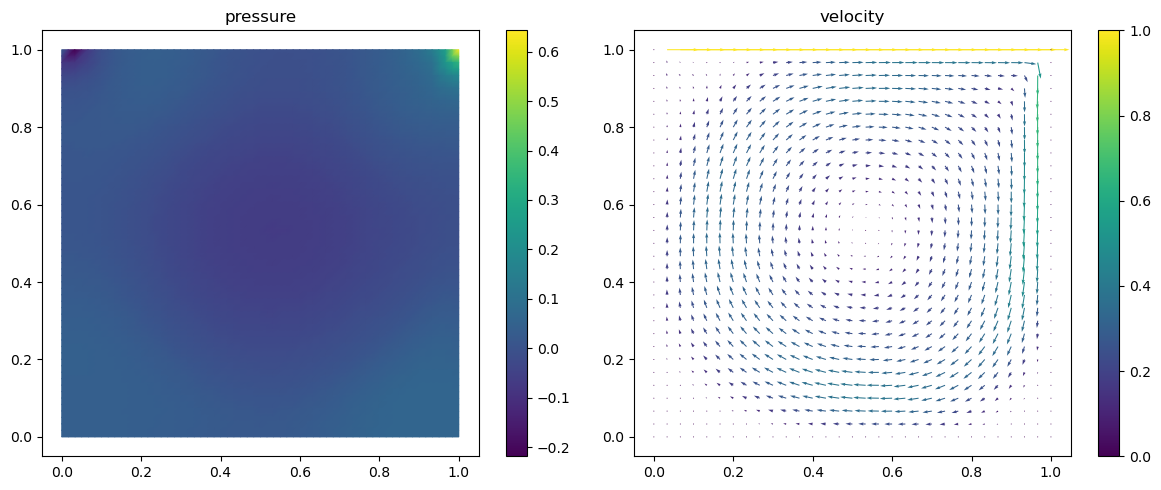

In [149]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

col0 = tripcolor(ph, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('pressure')

col1 = quiver(uh, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('velocity')

plt.tight_layout()

# Ex.2 NS: Stabilization (2).